Name: Ashley Qin, Natalie Chandler, Chloe Wang, Angel Lai, Rashi Adhikari

## PART 1: Wrangling and EDA

Demographic: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/DEMO.htm \
Mortality: https://www.cdc.gov/nchs/data/datalinkage/public-use-linked-mortality-file-description.pdf \
Caffeine: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/SSCAFE_A.htm 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Merge of mortality and demo into 'df'
mdf = pd.read_csv('linked_mortality_file_1999_2000.csv')
gdf = pd.read_sas("DEMO.xpt", format="xport")
df = gdf.merge(mdf, on="SEQN", how="inner")


### Description of Variables 

* ELIGSTAT (Eligibility Status for Mortality Follow-up): This variable shows whether or not a person is defined as eligible for mortality linkage due to insufficient identifying data. 
* MORTSTAT (Final Mortality Status): This variable determines the vital status of a participant and should be used when determining survival rates. Participants assumed alive are numbered 0 while while those assumed deceased are numbered 1. 
* PERMTH_INT (Number of Person Months of Follow-Up from NHANES Interview Date): This variable describes the number of person-months of the follow up from the interview date. 
* RIDAGEEX: This variable describes the age in months at the time the participant took the MEC exam. This data is only provided for those who were less than 85 years old at the time of the household screening interview. 

In [3]:
# Merge of df and caffeine dataset
cdf = pd.read_sas("SSCAFE_A.xpt", format="xport")
merged_df = cdf.merge(df, on="SEQN", how="inner")

### **ANSWER** Explain rationale for choosing this dataset

We chose the NHANES 1999–2000 caffeine dataset because it lets us connect biomarker-based caffeine exposure (urine caffeine/metabolites like SSMX1–SSMX7) with real long-term outcomes (MORTSTAT) while also controlling for basic demographics like age (RIDAGEEX) and sex (RIAGENDR). Since NHANES is nationally sampled and the mortality linkage provides follow-up time (PERMTH_INT), it’s a good dataset for asking whether higher measured caffeine exposure is associated with mortality risk.

### **ANSWER** Document any missing values here

In [4]:
# Choosing variables of interest
cols = ["SEQN", "ELIGSTAT", "MORTSTAT", "PERMTH_INT", "RIDAGEEX", "RIAGENDR",
        "WTSSCAF2", "WTSSCAF4", "SSMX1", "SSMX1LC","SSMX2", "SSMX2LC","SSMX3", "SSMX3LC",
        "SSMX4", "SSMX4LC", "SSMX5", "SSMX5LC", "SSMX6", "SSMX6LC",
        "SSMX7", "SSMX7LC"]
new_df = merged_df[cols].copy()
new_df.to_csv("working_df.csv", index=False)
pd.set_option('display.max_columns', None)
new_df.head()


,SEQN,ELIGSTAT,MORTSTAT,PERMTH_INT,RIDAGEEX,RIAGENDR,WTSSCAF2,WTSSCAF4,SSMX1,SSMX1LC,SSMX2,SSMX2LC,SSMX3,SSMX3LC,SSMX4,SSMX4LC,SSMX5,SSMX5LC,SSMX6,SSMX6LC,SSMX7,SSMX7LC
0,3.0,2,NaN,NaN,126.0,2.0,155825.292773,81908.618596,30.80,5.397605e-79,20.10,5.397605e-79,45.40,5.397605e-79,0.95,5.397605e-79,10.900,5.397605e-79,11.80,5.397605e-79,0.63,5.397605e-79
1,10.0,1,1.0,231.0,518.0,1.0,83707.269908,43060.890405,116.00,5.397605e-79,61.70,5.397605e-79,130.00,5.397605e-79,1.53,5.397605e-79,18.700,5.397605e-79,17.30,5.397605e-79,1.25,5.397605e-79
2,15.0,1,0.0,231.0,460.0,2.0,382453.382288,179126.737330,208.00,5.397605e-79,86.90,5.397605e-79,177.00,5.397605e-79,4.96,5.397605e-79,52.200,5.397605e-79,48.90,5.397605e-79,4.28,5.397605e-79
3,16.0,1,1.0,63.0,NaN,2.0,59345.928641,37637.555198,1.44,5.397605e-79,16.80,5.397605e-79,21.20,5.397605e-79,0.02,1.000000e+00,0.072,5.397605e-79,5.75,5.397605e-79,0.04,1.000000e+00
4,20.0,1,0.0,245.0,286.0,2.0,53884.837911,32614.899512,41.50,5.397605e-79,3.34,5.397605e-79,8.73,5.397605e-79,1.48,5.397605e-79,28.300,5.397605e-79,4.42,5.397605e-79,2.68,5.397605e-79


In [15]:
new_df.isna().sum()

SEQN            0
ELIGSTAT        0
MORTSTAT      942
PERMTH_INT    942
RIDAGEEX       53
RIAGENDR        0
WTSSCAF2        0
WTSSCAF4        0
SSMX1         592
SSMX1LC       592
SSMX2         592
SSMX2LC       592
SSMX3         592
SSMX3LC       592
SSMX4         592
SSMX4LC       592
SSMX5         592
SSMX5LC       592
SSMX6         592
SSMX6LC       592
SSMX7         592
SSMX7LC       592
dtype: int64

### EDA and visualization

In [17]:
# ELIGSTAT, MORTSTAT, PERMTH_INT, and RIDAGEEX
new_df[['ELIGSTAT', 'MORTSTAT', 'PERMTH_INT', 'RIDAGEEX']].head()

,ELIGSTAT,MORTSTAT,PERMTH_INT,RIDAGEEX
0,2,NaN,NaN,126.0
1,1,1.0,231.0,518.0
2,1,0.0,231.0,460.0
3,1,1.0,63.0,NaN
4,1,0.0,245.0,286.0


In [19]:
# Skew and outliers
new_df[['ELIGSTAT', 'MORTSTAT', 'PERMTH_INT', 'RIDAGEEX']].describe()

,ELIGSTAT,MORTSTAT,PERMTH_INT,RIDAGEEX
count,2648.000000,1706.000000,1706.000000,2595.000000
mean,1.356495,0.297186,205.650059,405.627746
std,0.480629,0.457153,63.690242,268.712502
min,1.000000,0.000000,1.000000,72.000000
25%,1.000000,0.000000,212.250000,179.500000
50%,1.000000,0.000000,235.000000,321.000000
75%,2.000000,1.000000,242.000000,613.500000
max,3.000000,1.000000,249.000000,1018.000000


<Axes: xlabel='variable', ylabel='value'>

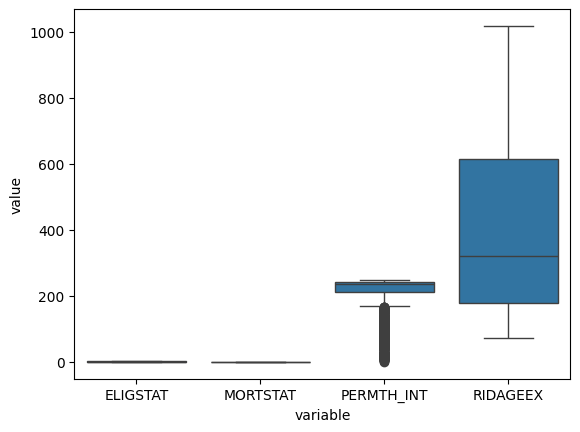

In [24]:
cols = ['ELIGSTAT', 'MORTSTAT', 'PERMTH_INT', 'RIDAGEEX']

df_long = new_df[cols].melt(var_name="variable", value_name="value")

sns.boxplot(data=df_long, x="variable", y="value")

array([[<Axes: title={'center': 'ELIGSTAT'}>,
        <Axes: title={'center': 'MORTSTAT'}>],
       [<Axes: title={'center': 'PERMTH_INT'}>,
        <Axes: title={'center': 'RIDAGEEX'}>]], dtype=object)

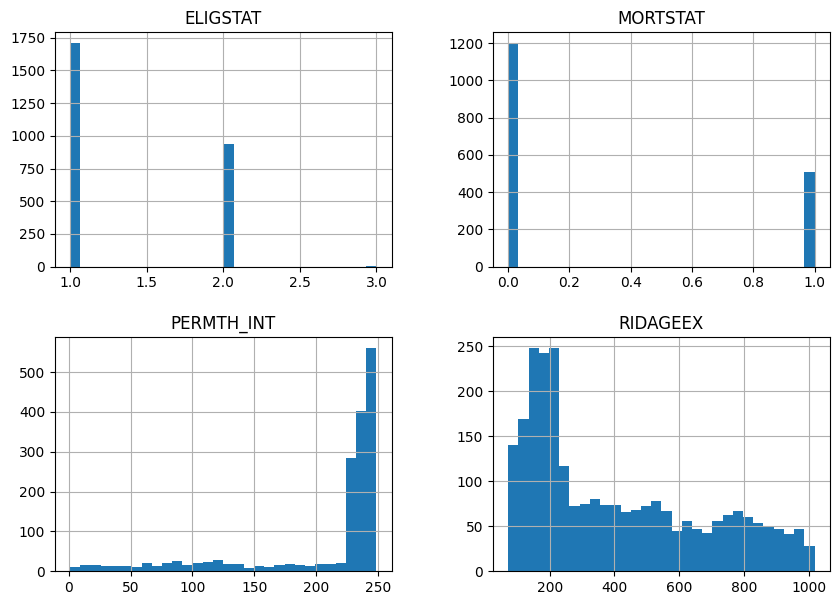

In [21]:
new_df[['ELIGSTAT', 'MORTSTAT', 'PERMTH_INT', 'RIDAGEEX']].hist(bins=30, figsize=(10,7))

array([[<Axes: title={'center': 'SSMX7'}>,
        <Axes: title={'center': 'SSMX5'}>,
        <Axes: title={'center': 'SSMX4'}>],
       [<Axes: title={'center': 'SSMX6'}>,
        <Axes: title={'center': 'SSMX1'}>,
        <Axes: title={'center': 'SSMX2'}>],
       [<Axes: title={'center': 'SSMX3'}>, <Axes: >, <Axes: >]],
      dtype=object)

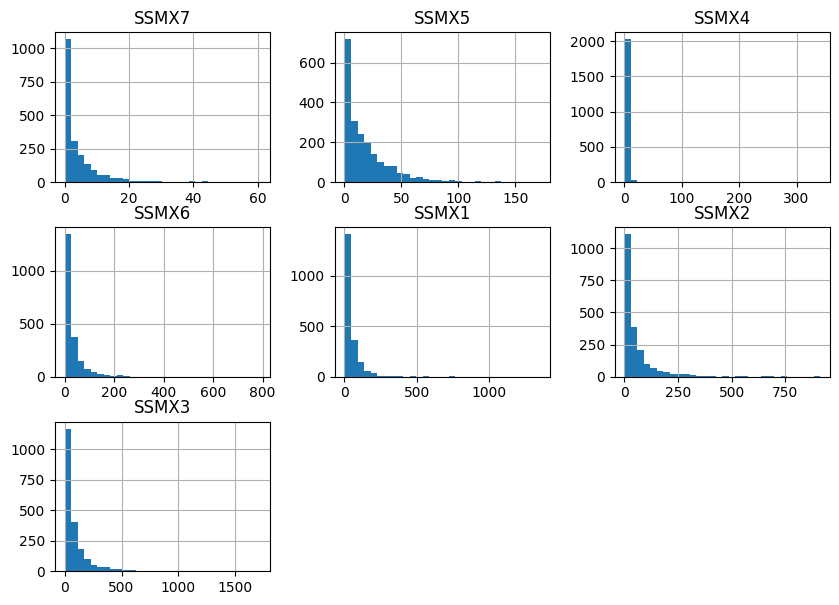

In [22]:
new_df[['SSMX7', 'SSMX5', 'SSMX4', 'SSMX6', 'SSMX1', 'SSMX2', 'SSMX3']].hist(bins=30, figsize=(10,7))

<Axes: xlabel='variable', ylabel='value'>

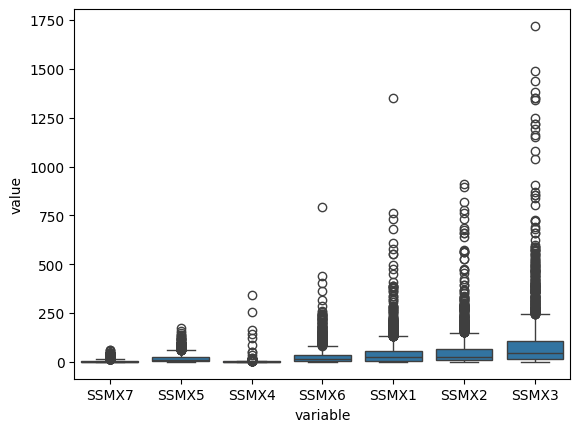

In [25]:
coffee = ['SSMX7', 'SSMX5', 'SSMX4', 'SSMX6', 'SSMX1', 'SSMX2', 'SSMX3']

df_long = new_df[coffee].melt(var_name="variable", value_name="value")

sns.boxplot(data=df_long, x="variable", y="value")

In [26]:
new_df[['SSMX7', 'SSMX5', 'SSMX4', 'SSMX6', 'SSMX1', 'SSMX2', 'SSMX3']].describe()

,SSMX7,SSMX5,SSMX4,SSMX6,SSMX1,SSMX2,SSMX3
count,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000
mean,4.470822,18.545646,2.651804,30.624553,46.181600,56.552510,95.893230
std,6.789654,21.345290,11.301862,45.806068,73.467346,88.972368,157.950584
min,0.040000,0.005000,0.020000,0.010000,0.120000,0.030000,0.010000
25%,0.397500,3.260000,0.380000,5.487500,6.832500,9.620000,15.200000
50%,1.910000,11.500000,1.250000,15.300000,23.900000,27.450000,44.400000
75%,5.672500,26.100000,2.820000,36.725000,57.400000,65.725000,107.000000
max,60.800000,172.000000,341.000000,791.000000,1350.000000,912.000000,1720.000000


In [29]:
corr_vars = [
    "RIDAGEEX",
    "SSMX1","SSMX2","SSMX3","SSMX4","SSMX5","SSMX6","SSMX7"
]

corr_df = new_df[corr_vars].dropna()
corr_mat = corr_df.corr(method="pearson")

corr_mat

,RIDAGEEX,SSMX1,SSMX2,SSMX3,SSMX4,SSMX5,SSMX6,SSMX7
RIDAGEEX,1.000000,0.068582,-0.070670,-0.144777,0.124209,0.146617,-0.163275,0.276511
SSMX1,0.068582,1.000000,0.301542,0.298036,0.151592,0.670791,0.148899,0.429994
SSMX2,-0.070670,0.301542,1.000000,0.913232,0.150596,0.164132,0.770022,0.112654
SSMX3,-0.144777,0.298036,0.913232,1.000000,0.011158,0.139595,0.775259,0.016782
SSMX4,0.124209,0.151592,0.150596,0.011158,1.000000,0.210920,0.035705,0.226017
SSMX5,0.146617,0.670791,0.164132,0.139595,0.210920,1.000000,0.217979,0.690028
SSMX6,-0.163275,0.148899,0.770022,0.775259,0.035705,0.217979,1.000000,0.112140
SSMX7,0.276511,0.429994,0.112654,0.016782,0.226017,0.690028,0.112140,1.000000


In [30]:
pd.crosstab(df["RIAGENDR"], df["MORTSTAT"], normalize="index")

MORTSTAT,0.0,1.0
RIAGENDR,,
1.0,0.653454,0.346546
2.0,0.726614,0.273386


**Urine caffeine biomarkers (SSMX variables)description:**
SSMX1: 1-methylxanthine

SSMX2: 3-methylxanthine

SSMX3: 7-methylxanthine

SSMX4: theophylline (1,3-dimethylxanthine)

SSMX5: paraxanthine (1,7-dimethylxanthine)

SSMX6: theobromine (3,7-dimethylxanthine)

SSMX7: caffeine (1,3,7-trimethylxanthine)



Based off EDA **ANSWER**

**1) Are any important variables skewed?**

Yes. The urine caffeine/metabolite variables are strongly right-skewed. In the histograms for SSMX1–SSMX7, most participants are clustered near very small values, and there’s a long tail of people with much higher measurements. You can also see this in describe(). For example, SSMX3 has a median around 44.4 but a max near 1720, which shows a long right tail. The same pattern shows up for SSMX5 (median ~11.5, max ~172) and SSMX4 (median ~1.25, max ~341). This matters because the model can get dominated by the extreme high values if we don’t handle the skew.

**2) Are there outliers?**

Yes. especially in the metabolite variables. The boxplot for SSMX1–SSMX7 shows a lot of points way above the main box, basically a tons of high outliers. SSMX3 stands out the most since it has the largest spread and the highest extreme values. This matches what we see in the summary table, the gap between the 75th percentile and the max is huge for several SSMX variables.

**3) How correlated are pairs of variables?**

Most relationships with age (RIDAGEEX) are still weak. The biggest age link is with SSMX7 (r ≈ 0.28), which is still not “strong,” just a small positive association. The strongest correlations are between the caffeine metabolite variables themselves, especially SSMX2–SSMX3 (r ≈ 0.91), and then SSMX3–SSMX6 (r ≈ 0.78) and SSMX2–SSMX6 (r ≈ 0.77), which are pretty strong and suggest those measures move together a lot. We also see a moderate-to-strong relationship for SSMX1–SSMX5 (r ≈ 0.67) and SSMX5–SSMX7 (r ≈ 0.69), meaning some metabolites are clustered and may be partly redundant in a model. It is expected that caffine metabolic variables are positively correlated with each other as they’re all tied to caffeine exposure/metabolism, so people with high caffeine biomarkers often have multiple metabolites elevated. 

**4) Do pairs of categorical variables exhibit interesting patterns in contingency tables?**

**5) Provide a clear discussion and examination of the data and the variables you are interested in using.**
Our goal is to model mortality status (MORTSTAT) using basic demographics like age (RIDAGEEX) and sex (RIAGENDR) plus urine caffeine/metabolite biomarkers. The main biomarkers we focus on are SSMX3, SSMX4, and SSMX5, which are all urine measures related to caffeine exposure/metabolism. The EDA shows two big data issues we have to account for:
(1) the SSMX variables are very skewed with many extreme outliers, and
(2) mortality variables like MORTSTAT and PERMTH_INT are only available for a subset of participants.

## Part 2: KNN Classification/Regression

### 1) Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? 

**The dataset is made up of a few important columns, namely the sequence number (SEQN), the eligibility status (ELIGSTAT), the death status (MORTSTAT). It also includes the demographic variables such as age (in months) and gender (1 = male, 2 = female). Included is also a few variables from the caffeine dataset including the representative weight (we are using WTSSCAF2 since we are looking at 1 cycle from 1999-2000), and several metabolites SSMX1-7 along wit their LC (lab comment version). We are looking at SSMX1 specifically because it represents how much caffeine an individual was exposed to. We ignore the LC version during regression**\
**There are sme missing data. Particularly, there are 942 missing data from the mortality status column out of 2648, which need to be removed before we can regress on it. There are also 53 missing ages, which isn't particularly important so we can either keep or remove it. In addition, for each of the caffeine metabolites, there are 592 values missing out of 2648. Since we are looking at the relationship between SSMX1 and death, we need to drop these NA's.** \
**The data was collected by NHANES to see if there is a broader implicaton of consumption of caffeine on the health of the general public. Caffeine is so accessible and many people consume it daily. The data is collected through random sampling and use of physical exams and urine samples in this dataset.**\
**There are several limitations. First, we are looking at caffeine intake at a singular point in time, not over the course of a long time. Therefore, we may not be able to say that long-term habitual caffeine consumption is linked to death. In addition, we do not take into consideration any confounding variables like presdispositions, prior health issues, and anything beyond age and sex.**


In [13]:
print(new_df.shape)
new_df.isna().sum()

(2648, 22)


SEQN            0
ELIGSTAT        0
MORTSTAT      942
PERMTH_INT    942
RIDAGEEX       53
RIAGENDR        0
WTSSCAF2        0
WTSSCAF4        0
SSMX1         592
SSMX1LC       592
SSMX2         592
SSMX2LC       592
SSMX3         592
SSMX3LC       592
SSMX4         592
SSMX4LC       592
SSMX5         592
SSMX5LC       592
SSMX6         592
SSMX6LC       592
SSMX7         592
SSMX7LC       592
dtype: int64

In [14]:
new_df.describe()

,SEQN,ELIGSTAT,MORTSTAT,PERMTH_INT,RIDAGEEX,RIAGENDR,WTSSCAF2,WTSSCAF4,SSMX1,SSMX1LC,SSMX2,SSMX2LC,SSMX3,SSMX3LC,SSMX4,SSMX4LC,SSMX5,SSMX5LC,SSMX6,SSMX6LC,SSMX7,SSMX7LC
count,2648.000000,2648.000000,1706.000000,1706.000000,2595.000000,2648.000000,2.648000e+03,2.648000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03
mean,5015.427870,1.356495,0.297186,205.650059,405.627746,1.524169,9.387972e+04,4.523310e+04,46.181600,5.397605e-79,56.552510,7.782101e-03,95.893230,4.863813e-04,2.651804,5.496109e-02,18.545646,1.410506e-02,30.624553,3.404669e-03,4.470822,1.021401e-01
std,2874.909231,0.480629,0.457153,63.690242,268.712502,0.499510,1.173340e+05,5.455318e+04,73.467346,0.000000e+00,88.972368,8.789367e-02,157.950584,2.205405e-02,11.301862,2.279597e-01,21.345290,1.179528e-01,45.806068,5.826430e-02,6.789654,3.029061e-01
min,3.000000,1.000000,0.000000,1.000000,72.000000,1.000000,5.397605e-79,5.397605e-79,0.120000,5.397605e-79,0.030000,5.397605e-79,0.010000,5.397605e-79,0.020000,5.397605e-79,0.005000,5.397605e-79,0.010000,5.397605e-79,0.040000,5.397605e-79
25%,2534.000000,1.000000,0.000000,212.250000,179.500000,1.000000,8.547617e+03,5.138477e+03,6.832500,5.397605e-79,9.620000,5.397605e-79,15.200000,5.397605e-79,0.380000,5.397605e-79,3.260000,5.397605e-79,5.487500,5.397605e-79,0.397500,5.397605e-79
50%,4914.500000,1.000000,0.000000,235.000000,321.000000,2.000000,3.597306e+04,1.882514e+04,23.900000,5.397605e-79,27.450000,5.397605e-79,44.400000,5.397605e-79,1.250000,5.397605e-79,11.500000,5.397605e-79,15.300000,5.397605e-79,1.910000,5.397605e-79
75%,7565.000000,2.000000,1.000000,242.000000,613.500000,2.000000,1.545717e+05,7.293606e+04,57.400000,5.397605e-79,65.725000,5.397605e-79,107.000000,5.397605e-79,2.820000,5.397605e-79,26.100000,5.397605e-79,36.725000,5.397605e-79,5.672500,5.397605e-79
max,9961.000000,3.000000,1.000000,249.000000,1018.000000,2.000000,9.091403e+05,3.577499e+05,1350.000000,5.397605e-79,912.000000,1.000000e+00,1720.000000,1.000000e+00,341.000000,1.000000e+00,172.000000,1.000000e+00,791.000000,1.000000e+00,60.800000,1.000000e+00


### 2) Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice?

**The variables that were chosen are SSMX3, SSMX5, SSMX4. The SSMX variables are caffeine and caffeine metabolites that are sampeled from the urine of the participants. We chose these variables because they are all some type of variation of what contains caffeine. Out of the 7 types of caffeine, these were chosen because some of the SSMXs were highly correlated so we eliminated the ones that were too high. SSMX3 and SSMX5 have the highest variance and SSMX has the lowest correlation to the rest of the data.**

In [15]:
dfWork = pd.read_csv('working_df.csv', index_col=False)
dfWork.columns

Index(['SEQN', 'ELIGSTAT', 'MORTSTAT', 'PERMTH_INT', 'RIDAGEEX', 'RIAGENDR',
       'WTSSCAF2', 'WTSSCAF4', 'SSMX1', 'SSMX1LC', 'SSMX2', 'SSMX2LC', 'SSMX3',
       'SSMX3LC', 'SSMX4', 'SSMX4LC', 'SSMX5', 'SSMX5LC', 'SSMX6', 'SSMX6LC',
       'SSMX7', 'SSMX7LC'],
      dtype='object')

In [16]:
dfWork[['WTSSCAF2', 'WTSSCAF4', 'SSMX1', 'SSMX1LC', 'SSMX2', 'SSMX2LC', 'SSMX3',
       'SSMX3LC','SSMX4', 'SSMX4LC', 'SSMX5', 'SSMX5LC', 'SSMX6','SSMX6LC', 'SSMX7', 'SSMX7LC']].describe()

,WTSSCAF2,WTSSCAF4,SSMX1,SSMX1LC,SSMX2,SSMX2LC,SSMX3,SSMX3LC,SSMX4,SSMX4LC,SSMX5,SSMX5LC,SSMX6,SSMX6LC,SSMX7,SSMX7LC
count,2.648000e+03,2.648000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03,2056.000000,2.056000e+03
mean,9.387972e+04,4.523310e+04,46.181600,5.397605e-79,56.552510,7.782101e-03,95.893230,4.863813e-04,2.651804,5.496109e-02,18.545646,1.410506e-02,30.624553,3.404669e-03,4.470822,1.021401e-01
std,1.173340e+05,5.455318e+04,73.467346,0.000000e+00,88.972368,8.789367e-02,157.950584,2.205405e-02,11.301862,2.279597e-01,21.345290,1.179528e-01,45.806068,5.826430e-02,6.789654,3.029061e-01
min,5.397605e-79,5.397605e-79,0.120000,5.397605e-79,0.030000,5.397605e-79,0.010000,5.397605e-79,0.020000,5.397605e-79,0.005000,5.397605e-79,0.010000,5.397605e-79,0.040000,5.397605e-79
25%,8.547617e+03,5.138477e+03,6.832500,5.397605e-79,9.620000,5.397605e-79,15.200000,5.397605e-79,0.380000,5.397605e-79,3.260000,5.397605e-79,5.487500,5.397605e-79,0.397500,5.397605e-79
50%,3.597306e+04,1.882514e+04,23.900000,5.397605e-79,27.450000,5.397605e-79,44.400000,5.397605e-79,1.250000,5.397605e-79,11.500000,5.397605e-79,15.300000,5.397605e-79,1.910000,5.397605e-79
75%,1.545717e+05,7.293606e+04,57.400000,5.397605e-79,65.725000,5.397605e-79,107.000000,5.397605e-79,2.820000,5.397605e-79,26.100000,5.397605e-79,36.725000,5.397605e-79,5.672500,5.397605e-79
max,9.091403e+05,3.577499e+05,1350.000000,5.397605e-79,912.000000,1.000000e+00,1720.000000,1.000000e+00,341.000000,1.000000e+00,172.000000,1.000000e+00,791.000000,1.000000e+00,60.800000,1.000000e+00


In [17]:
dfWork[['SSMX1','SSMX2','SSMX3','SSMX4','SSMX5','SSMX6','SSMX7']].corr()

,SSMX1,SSMX2,SSMX3,SSMX4,SSMX5,SSMX6,SSMX7
SSMX1,1.000000,0.297780,0.299012,0.136825,0.672095,0.150703,0.427807
SSMX2,0.297780,1.000000,0.889406,0.233156,0.162339,0.749021,0.116570
SSMX3,0.299012,0.889406,1.000000,0.004964,0.142598,0.775901,0.018302
SSMX4,0.136825,0.233156,0.004964,1.000000,0.177982,0.024164,0.195095
SSMX5,0.672095,0.162339,0.142598,0.177982,1.000000,0.221211,0.683001
SSMX6,0.150703,0.749021,0.775901,0.024164,0.221211,1.000000,0.111109
SSMX7,0.427807,0.116570,0.018302,0.195095,0.683001,0.111109,1.000000


/tmp/ipykernel_37603/3387313609.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


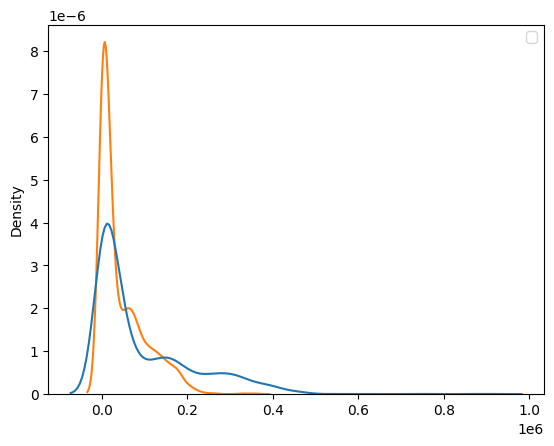

In [18]:
sns.kdeplot(data=dfWork[['WTSSCAF2','WTSSCAF4']])
plt.legend()
plt.show()

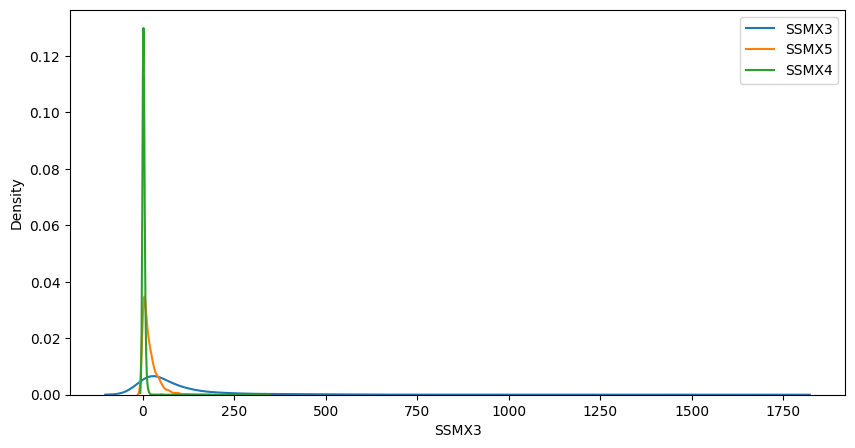

In [19]:
plt.figure(figsize=(10, 5))

sns.kdeplot(dfWork['SSMX3'], label='SSMX3')
sns.kdeplot(dfWork['SSMX5'], label='SSMX5')
sns.kdeplot(dfWork['SSMX4'], label='SSMX4')

plt.legend()
plt.show()

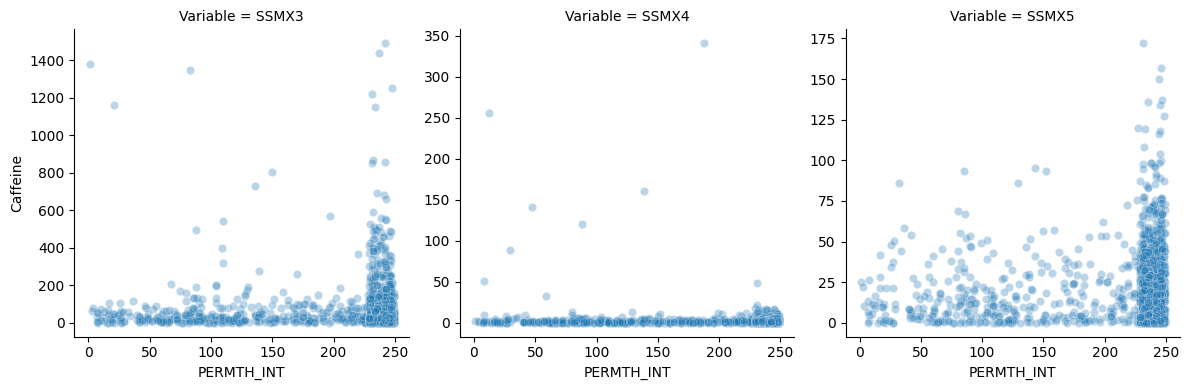

In [20]:
df_long = dfWork[['PERMTH_INT','SSMX3','SSMX4','SSMX5']].melt(
    id_vars='PERMTH_INT',
    var_name='Variable',
    value_name='Caffeine'
)

g = sns.FacetGrid(df_long, col='Variable', height=4, sharey=False)
g.map_dataframe(sns.scatterplot, x='PERMTH_INT', y='Caffeine', alpha=0.3)

plt.show()

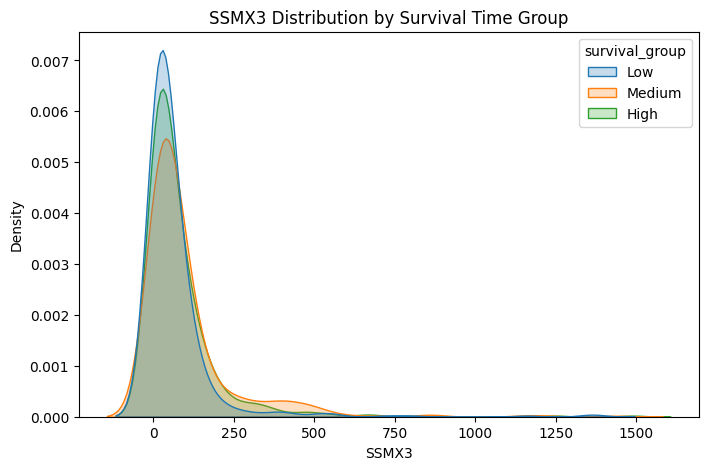

In [21]:
# conditional kde with PERMTH_INT
dfWork['survival_group'] = pd.qcut(dfWork['PERMTH_INT'], 3, labels=['Low','Medium','High'])

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=dfWork,
    x='SSMX3',
    hue='survival_group',
    fill=True,
    common_norm=False
)

plt.title("SSMX3 Distribution by Survival Time Group")
plt.show()

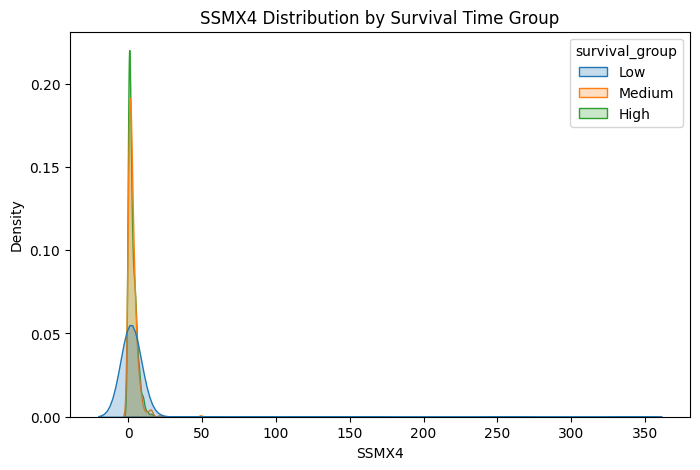

In [22]:
# conditional kde with PERMTH_INT
dfWork['survival_group'] = pd.qcut(dfWork['PERMTH_INT'], 3, labels=['Low','Medium','High'])

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=dfWork,
    x='SSMX4',
    hue='survival_group',
    fill=True,
    common_norm=False
)

plt.title("SSMX4 Distribution by Survival Time Group")
plt.show()

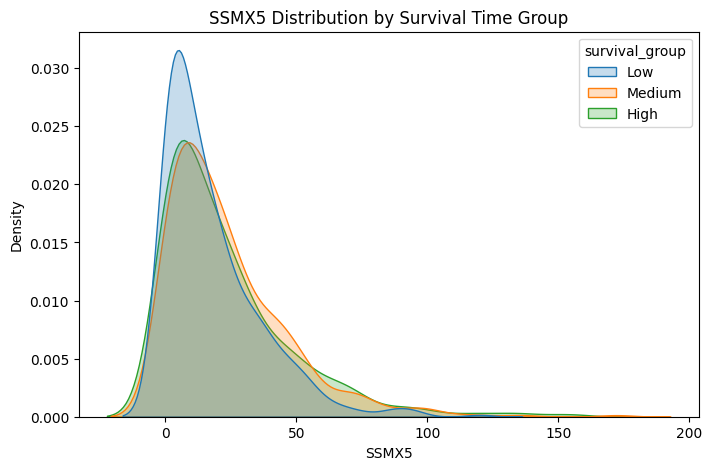

In [23]:
# conditional kde with PERMTH_INT
dfWork['survival_group'] = pd.qcut(dfWork['PERMTH_INT'], 3, labels=['Low','Medium','High'])

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=dfWork,
    x='SSMX5',
    hue='survival_group',
    fill=True,
    common_norm=False
)

plt.title("SSMX5 Distribution by Survival Time Group")
plt.show()

**Patterns: for both SSMX3 and SSMX4, they both mainly bunched up closer to the x-axis, with SSMX having more spread and outliers. Towards 250 though, all the SSMX variables had a lot of values becoming vertically increasing. SSMX5 was the most spread out of all the variables. We decided to separate the PERMTH_INT life expectnancy into different categories. They were separated into equal low, medium, and high survival groups. SSMX3 had groups that were closer together, but most had low survival rates. Its distributions were relatively similar. For SSMX4, high was had a larger distribution with medium following closely behind. SSMX5 had its highest distribution go to the low survival group with medium and high being closer in distirbution.**

### 3. Using your variables to predict mortality using a k-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select k.

In [24]:
#We used the three variables SSMX3, SSMX4, SSMX5 to predict MORTSTAT.
#First, import relevant libraries and modules. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

#Next, update and load cleaned dataset and keep relevant columns
merged_df = pd.read_csv("merged_demo_mortality_caffeine.csv")
cols = ["SEQN", "ELIGSTAT", "MORTSTAT", "PERMTH_INT", "RIDAGEEX", "RIAGENDR",
        "WTSSCAF2", "WTSSCAF4",
        "SSMX3", "SSMX3LC", "SSMX4", "SSMX4LC", "SSMX5", "SSMX5LC",
        "SSMX6", "SSMX6LC", "SSMX7", "SSMX7LC"]

working_df = merged_df[cols].copy()
working_df.to_csv("working_df.csv", index=False)
df_q3 = working_df[["MORTSTAT", "SSMX3", "SSMX4", "SSMX5"]].dropna()

In [25]:
X = df_q3[["SSMX3", "SSMX4", "SSMX5"]]
y = df_q3["MORTSTAT"].astype(int)

#Split the data into training and testing (80% vs 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#standardized the variables to prevent bias in distance-based algorithms like KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
#Testing k values between 1 and 20 and selecting the highest accuracy to determine the best k for KNN
k_values = range(1, 21)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
best_k = k_values[np.argmax(accuracies)]
print("Best k:", best_k)

Best k: 8


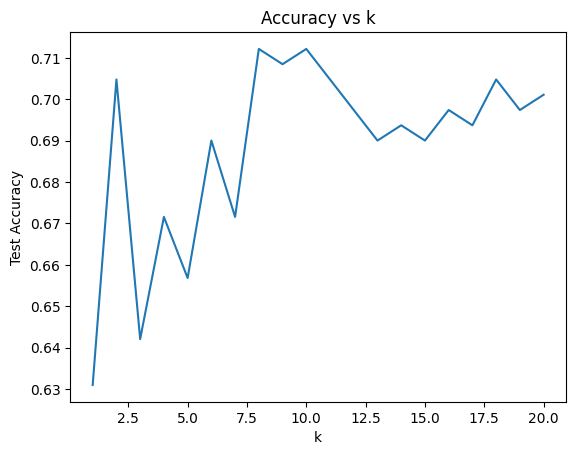

In [27]:
plt.plot(k_values, accuracies)
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs k")
plt.show()
#This graph shows which k value gives the highest accuracy, which is 8 in this case.

In [28]:
#Fit the final kNN model using the selected best value of k 
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
#Finally, generate predictions on the test set and evaluate the final model's performance
y_final_pred = final_model.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, y_final_pred))

Final Accuracy: 0.7121771217712177


To predict MORTSTAT, I used a k-Nearest classifier with the variables SSMX3, SSMX4, and SSMX5 as predictors. After cleaning and removing missing variables and keeping only relevant columns, I split the data into 80% training and 20% testing. Additionally, I standardized the predictors before fitting the model.

Next, to select k, I tested values from 1 to 20 and calculated the testing accuracy for each value, as done on the homework. Finally, upon looking at the graph and calculations, I chose the k that produced the highest test accuracy. This is important as a small k value overfits data, while large k values tend to overfit. Selecting a k with the highest test accuracy reduces bias and variance in the data.

Finally, using the optimal k, I created the final model with a test accuracy of 0.7121771217712177.

### 4. Using your variables to predict life expectancy using a $k$ -Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [30]:
# update and load cleaned dataset and keep relevant columns
merged_df = pd.read_csv("merged_demo_mortality_caffeine.csv")
cols = ["SEQN", "ELIGSTAT", "MORTSTAT", "PERMTH_INT", "RIDAGEEX", "RIAGENDR",
        "WTSSCAF2", "WTSSCAF4",
        "SSMX3", "SSMX3LC", "SSMX4", "SSMX4LC", "SSMX5", "SSMX5LC",
        "SSMX6", "SSMX6LC", "SSMX7", "SSMX7LC"]

working_df = merged_df[cols].copy()
working_df.to_csv("working_df.csv", index=False)
df_q4 = working_df[["PERMTH_INT", "SSMX3", "SSMX4", "SSMX5"]].dropna()

# Select predictors and outcome
X = df_q4[['SSMX3', 'SSMX5', 'SSMX4']]
y = df_q4['PERMTH_INT']

# Drop missing values
data = pd.concat([X, y], axis=1).dropna()

X = data[['SSMX3', 'SSMX4', 'SSMX5']]
y = data['PERMTH_INT']

In [31]:
# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# standardize predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# select k from minimum MSE
k_values = [3, 5, 10, 20, 50, 100]
mse_results = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mse_results.append(mse)
    
    print(f"k = {k}, MSE = {mse}")

best_k = k_values[np.argmin(mse_results)]
print("Optimal k:", best_k)

k = 3, MSE = 5729.663796637967
k = 5, MSE = 5244.971955719557
k = 10, MSE = 5068.982435424355
k = 20, MSE = 4875.856439114391
k = 50, MSE = 4856.2126966789665
k = 100, MSE = 4855.067499261992
Optimal k: 100


In [34]:
# Retrain using training data and optimal k
best_knn = KNeighborsRegressor(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = best_knn.predict(X_test_scaled)

In [35]:
# Evaluate model performance using RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 69.678314411745


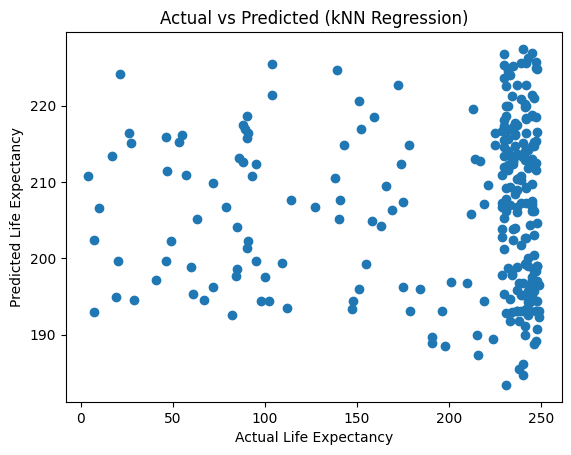

In [36]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted (kNN Regression)")
plt.show()

### 5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider?

**Our model can take someone’s basic info like age (RIDAGEEX) and sex (RIAGENDR), along with their urine caffeine metabolite levels, and estimate their mortality risk over the NHANES follow-up period. We used SSMX3 (7-methylxanthine), SSMX4 (theophylline), and SSMX5 (paraxanthine), since they’re all measurable breakdown products related to caffeine exposure. In a clinic or public health setting, this kind of estimate could help staff decide who might need a little more follow-up first, like a quick conversation about caffeine habits, checking related issues such as sleep and blood pressure, or recommending lifestyle changes and monitoring sooner.**

**A few limits matter. This model shows correlation, not causation, so a higher predicted risk does not mean caffeine is the direct cause. Things like smoking, existing disease, medications, and socioeconomic factors could be part of what the model is picking up. The model might also work better for some groups than others, such as certain ages or sexes, which could lead to less accurate guidance if you do not check for that. Finally, because the data comes from NHANES 1999–2000, it may not fully match today’s caffeine products and health patterns, so it would need testing before being used in modern settings.**